# Korpus-Analyse: Semantische Ähnlichkeit, Textlängen, TTR & MATTR

Dieses Notebook bietet eine eingehende linguistische und korpusdiagnostische Analyse des parallelen Korpus (Alltagssprache **AS** vs. Leichte Sprache **LS**).

### Analysierte Dimensionen:
1. **Verteilung der Textlängen**: Token- und Wortanzahlen, Längenverhältnisse (Kompression vs. Expansion) und Perzentile über verschiedene Quellen.
2. **Semantische Ähnlichkeit**: Verteilung der paarweisen Cosine Similarity (SBERT Jina 8192) über das Gesamtkorpus und aufgeschlüsselt nach Quellen.
3. **Lexikalische Vielfalt (TTR - Type-Token Ratio)**: Analyse der klassischen TTR ($V/N$), deren Vergleich zwischen AS und LS sowie Untersuchung des textlängenbedingten TTR-Bias.
4. **Robuste lexikalische Vielfalt (MATTR - Moving-Average Type-Token Ratio)**: Fensterbasierte MATTR ($W=50$), Gegenüberstellung zu TTR und Nachweis der Längenunabhängigkeit.
5. **Multivariate Zusammenhänge**: Korrelationen zwischen Ähnlichkeit, Kompression, Lesbarkeit und Diversitätsmaßen.


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot-Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 11

print("Bibliotheken erfolgreich importiert.")


Bibliotheken erfolgreich importiert.


## 1. Datensatz laden

Wir laden die Master-CSV-Datei (`../../data/analysis/corpus_master.csv`), die alle vorberechneten Textpaare und Metriken enthält.


In [4]:
CSV_PATH = "../../../data/analysis/corpus_master.csv"

df = pd.read_csv(CSV_PATH)
print(f"Erfolgreich {len(df)} Artikelpaare geladen.")

# Berechnung des Längenverhältnisses LS / AS
if "ratio_ls_as" not in df.columns and "as_tokens" in df.columns and "ls_tokens" in df.columns:
    df["ratio_ls_as"] = df["ls_tokens"] / df["as_tokens"]

print(f"Spalten im DataFrame ({len(df.columns)}):", list(df.columns))
df.head(3)


Erfolgreich 882 Artikelpaare geladen.
Spalten im DataFrame (25): ['source', 'as_url', 'ls_url', 'as_text', 'ls_text', 'semantic_similarity_8192', 'ner_recall_as_ls', 'ner_recall_ls_as', 'as_ent_count', 'ls_ent_count', 'as_tokens', 'ls_tokens', 'as_avg_sent_len', 'ls_avg_sent_len', 'as_flesch', 'as_wiener', 'as_lix', 'ls_flesch', 'ls_wiener', 'ls_lix', 'as_ttr', 'as_mattr', 'ls_ttr', 'ls_mattr', 'ratio_ls_as']


,source,as_url,ls_url,as_text,ls_text,semantic_similarity_8192,ner_recall_as_ls,ner_recall_ls_as,as_ent_count,ls_ent_count,...,as_wiener,as_lix,ls_flesch,ls_wiener,ls_lix,as_ttr,as_mattr,ls_ttr,ls_mattr,ratio_ls_as
0,hamburg,https://www.hamburg.de/politik-und-verwaltung/...,https://www.hamburg.de/barrierefrei/leichte-sp...,Individuelle Verbraucherberatung Die Durchführ...,Menschen in Hamburg kaufen viele Sachen. Zum B...,0.879659,0.250000,0.166667,16,24,...,10.239358,49.947368,62.186567,6.321347,39.463284,0.525210,0.729524,0.306667,0.682780,2.836134
1,hamburg,https://www.hamburg.de/politik-und-verwaltung/...,https://www.hamburg.de/barrierefrei/leichte-sp...,Pflegestützpunkte beraten hilfe- und pflegebed...,Es gibt viele Pflege-Stütz-Punkte in Hamburg. ...,0.877679,0.357143,0.227273,14,22,...,14.100879,62.920302,56.995873,7.156250,39.152565,0.562500,0.770039,0.345631,0.663691,1.694079
2,hamburg,https://www.hamburg.de/politik-und-verwaltung/...,https://www.hamburg.de/politik-und-verwaltung/...,Wozu Krebsregister Bei vielen Krebserkrankunge...,Infos über Menschen mit Krebs sammeln In Hambu...,0.842175,0.111111,0.041667,9,24,...,14.748595,66.666667,57.818949,7.166288,39.237961,0.540476,0.834447,0.218402,0.657702,2.354762


### 1.1 Algorithmen für TTR & MATTR (Referenzimplementierung)

Für Transparenz und Reproduzierbarkeit ist hier die mathematische und algorithmische Definition von TTR und MATTR hinterlegt:

- **Type-Token Ratio (TTR)**:
  $$TTR = \frac{|V|}{N}$$
  wobei $|V|$ die Anzahl der einzigartigen Lemmata/Wortformen (Types) und $N$ die Gesamtwortanzahl (Tokens) ist.

- **Moving-Average Type-Token Ratio (MATTR)**:
  Berechnung von TTR über ein gleitendes Fenster der festen Breite $W$ (Standard: $W=50$):
  $$MATTR = \frac{1}{N - W + 1} \sum_{i=1}^{N - W + 1} \frac{|V_{i, W}|}{W}$$


In [5]:
def compute_ttr_and_mattr(text, window_size=50):
    """
    Berechnet einfache Wort-Tokens, TTR und MATTR für einen gegebenen Textstring.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0, np.nan, np.nan
    
    # Einfache Tokenisierung: nur alphanumerische Wörter, kleingeschrieben
    tokens = re.findall(r'\b\w+\b', text.lower())
    n_tokens = len(tokens)
    if n_tokens == 0:
        return 0, np.nan, np.nan
    
    # 1. Classical TTR
    unique_types = len(set(tokens))
    ttr = unique_types / n_tokens
    
    # 2. MATTR
    if n_tokens < window_size:
        mattr = ttr
    else:
        window_ttrs = [
            len(set(tokens[i : i + window_size])) / window_size
            for i in range(n_tokens - window_size + 1)
        ]
        mattr = float(np.mean(window_ttrs))
        
    return n_tokens, ttr, mattr

# Test an einem kurzen Beispielsatz
test_as = "Die Europäische Union fördert barrierefreie Kommunikation in allen Mitgliedstaaten durch gezielte Richtlinien."
test_ls = "Die Europäische Union hilft. Alle Menschen sollen Texte gut verstehen. Dafür gibt es Regeln."

t_as, ttr_as, mattr_as = compute_ttr_and_mattr(test_as, window_size=5)
t_ls, ttr_ls, mattr_ls = compute_ttr_and_mattr(test_ls, window_size=5)

print(f"AS: {t_as} Tokens | TTR: {ttr_as:.3f} | MATTR(5): {mattr_as:.3f}")
print(f"LS: {t_ls} Tokens | TTR: {ttr_ls:.3f} | MATTR(5): {mattr_ls:.3f}")


AS: 12 Tokens | TTR: 1.000 | MATTR(5): 1.000
LS: 14 Tokens | TTR: 1.000 | MATTR(5): 1.000


## 2. Korpus-Übersicht nach Quellen

Deskriptive Kennzahlen für jede Datenquelle: Artikelpaare, Gesamttokens, durchschnittliche Längen, mittlere semantische Ähnlichkeit und Kompressionsrate.


In [6]:
# Aggregation pro Quelle
summary_cols = {}
if "as_tokens" in df.columns and "ls_tokens" in df.columns:
    summary_df = df.groupby("source").agg(
        Artikelpaare=("as_tokens", "count"),
        Tokens_AS_Gesamt=("as_tokens", "sum"),
        Tokens_LS_Gesamt=("ls_tokens", "sum"),
        Ø_Tokens_AS=("as_tokens", "mean"),
        Ø_Tokens_LS=("ls_tokens", "mean"),
        Ø_Ähnlichkeit=("semantic_similarity_8192", "mean") if "semantic_similarity_8192" in df.columns else ("as_tokens", "count"),
        Ø_TTR_AS=("as_ttr", "mean") if "as_ttr" in df.columns else ("as_tokens", "count"),
        Ø_TTR_LS=("ls_ttr", "mean") if "ls_ttr" in df.columns else ("as_tokens", "count"),
        Ø_MATTR_AS=("as_mattr", "mean") if "as_mattr" in df.columns else ("as_tokens", "count"),
        Ø_MATTR_LS=("ls_mattr", "mean") if "ls_mattr" in df.columns else ("as_tokens", "count")
    )
    summary_df["Längenratio_LS_AS"] = summary_df["Tokens_LS_Gesamt"] / summary_df["Tokens_AS_Gesamt"]

    # Gesamtsummen-Zeile
    total_row = pd.Series({
        "Artikelpaare": len(df),
        "Tokens_AS_Gesamt": df["as_tokens"].sum(),
        "Tokens_LS_Gesamt": df["ls_tokens"].sum(),
        "Ø_Tokens_AS": df["as_tokens"].mean(),
        "Ø_Tokens_LS": df["ls_tokens"].mean(),
        "Ø_Ähnlichkeit": df["semantic_similarity_8192"].mean() if "semantic_similarity_8192" in df.columns else np.nan,
        "Ø_TTR_AS": df["as_ttr"].mean() if "as_ttr" in df.columns else np.nan,
        "Ø_TTR_LS": df["ls_ttr"].mean() if "ls_ttr" in df.columns else np.nan,
        "Ø_MATTR_AS": df["as_mattr"].mean() if "as_mattr" in df.columns else np.nan,
        "Ø_MATTR_LS": df["ls_mattr"].mean() if "ls_mattr" in df.columns else np.nan,
        "Längenratio_LS_AS": df["ls_tokens"].sum() / df["as_tokens"].sum()
    }, name="GESAMT")

    summary_table = pd.concat([summary_df, pd.DataFrame([total_row])])
    display(summary_table.round(3))


,Artikelpaare,Tokens_AS_Gesamt,Tokens_LS_Gesamt,Ø_Tokens_AS,Ø_Tokens_LS,Ø_Ähnlichkeit,Ø_TTR_AS,Ø_TTR_LS,Ø_MATTR_AS,Ø_MATTR_LS,Längenratio_LS_AS
apotheken,154.0,183061.0,102106.0,1188.708,663.026,0.844,0.436,0.328,0.804,0.675,0.558
behindertenbeauftragter,49.0,19408.0,19192.0,396.082,391.673,0.862,0.499,0.420,0.756,0.693,0.989
brandeins,18.0,3404.0,3542.0,189.111,196.778,0.706,0.627,0.461,0.799,0.681,1.041
hamburg,49.0,23141.0,21874.0,472.265,446.408,0.820,0.530,0.366,0.772,0.657,0.945
hannover,229.0,112318.0,118437.0,490.472,517.192,0.839,0.509,0.355,0.768,0.653,1.054
koeln,37.0,19464.0,27699.0,526.054,748.622,0.823,0.454,0.315,0.752,0.670,1.423
main_taunus,34.0,5330.0,5353.0,156.765,157.441,0.816,0.652,0.570,0.789,0.722,1.004
mdr,222.0,76650.0,46148.0,345.270,207.874,0.792,0.573,0.470,0.803,0.703,0.602
sozialpolitik,14.0,11311.0,4912.0,807.929,350.857,0.780,0.484,0.433,0.804,0.711,0.434
stuttgart,37.0,32325.0,21275.0,873.649,575.000,0.838,0.429,0.365,0.761,0.686,0.658


## 3. Verteilung der Textlängen (Tokens & Ratio)

Untersuchung der Längenverteilung von Alltagssprache (AS) und Leichter Sprache (LS) sowie des Kompressions-/Expansionsverhaltens.


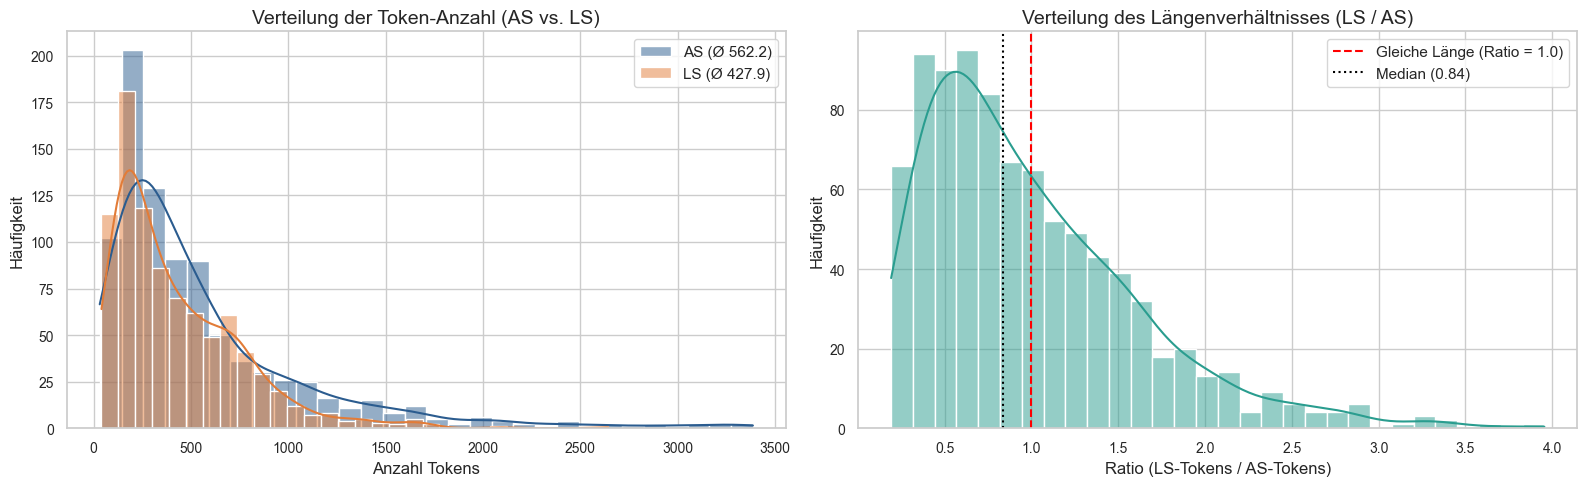

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3.1 Token-Verteilungen AS vs. LS (Histogramm + KDE)
sns.histplot(df["as_tokens"], kde=True, color="#2b5c8f", label=f"AS (Ø {df['as_tokens'].mean():.1f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_tokens"], kde=True, color="#e27c38", label=f"LS (Ø {df['ls_tokens'].mean():.1f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der Token-Anzahl (AS vs. LS)")
axes[0].set_xlabel("Anzahl Tokens")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 3.2 Längenverhältnis LS / AS (Kompression vs. Expansion)
if "ratio_ls_as" in df.columns:
    sns.histplot(df["ratio_ls_as"], kde=True, color="#2a9d8f", bins=30, ax=axes[1])
    axes[1].axvline(1.0, color="red", linestyle="--", label="Gleiche Länge (Ratio = 1.0)")
    axes[1].axvline(df["ratio_ls_as"].median(), color="black", linestyle=":", label=f"Median ({df['ratio_ls_as'].median():.2f})")
    axes[1].set_title("Verteilung des Längenverhältnisses (LS / AS)")
    axes[1].set_xlabel("Ratio (LS-Tokens / AS-Tokens)")
    axes[1].set_ylabel("Häufigkeit")
    axes[1].legend()

plt.tight_layout()
plt.show()


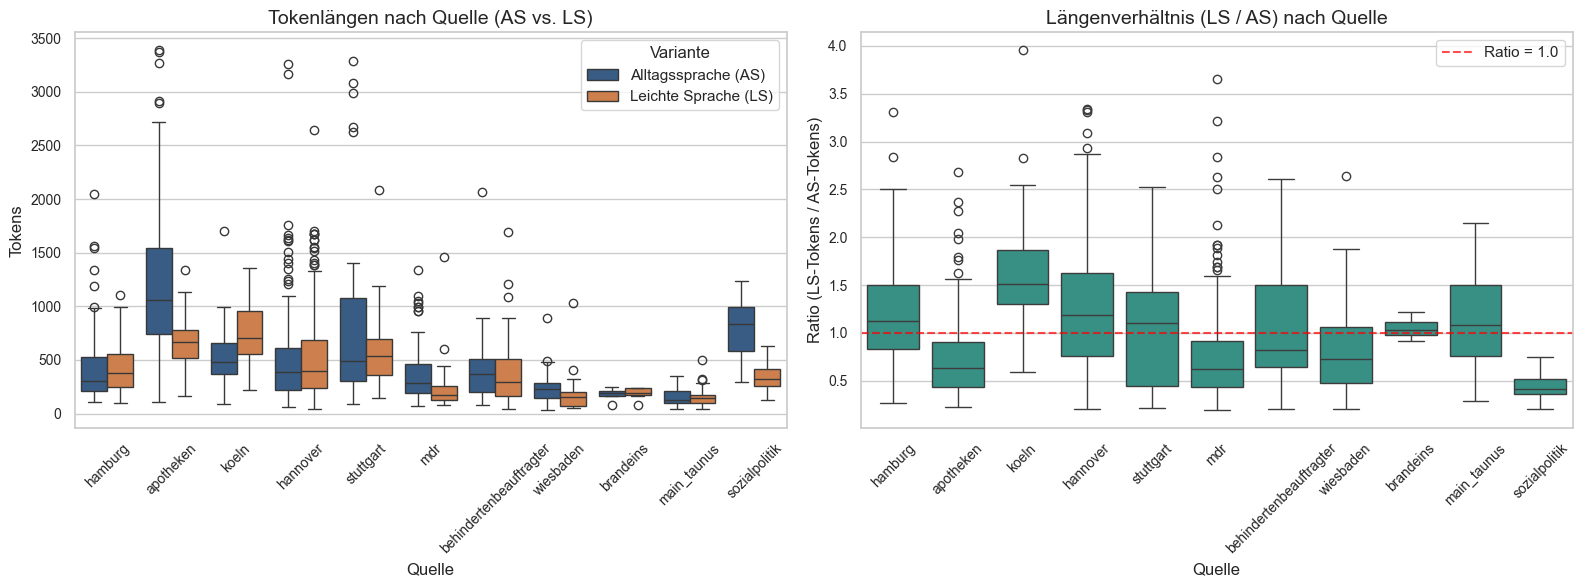

In [8]:
# Boxplot der Token-Längen nach Quellen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Melt DataFrame für kombiniertes Boxplot
df_melted = df.melt(id_vars=["source"], value_vars=["as_tokens", "ls_tokens"], 
                    var_name="Variante", value_name="Tokens")
df_melted["Variante"] = df_melted["Variante"].map({"as_tokens": "Alltagssprache (AS)", "ls_tokens": "Leichte Sprache (LS)"})

sns.boxplot(data=df_melted, x="source", y="Tokens", hue="Variante", palette=["#2b5c8f", "#e27c38"], ax=axes[0])
axes[0].set_title("Tokenlängen nach Quelle (AS vs. LS)")
axes[0].set_xlabel("Quelle")
axes[0].set_ylabel("Tokens")
axes[0].tick_params(axis="x", rotation=45)

# Boxplot des Längenverhältnisses nach Quellen
if "ratio_ls_as" in df.columns:
    sns.boxplot(data=df, x="source", y="ratio_ls_as", color="#2a9d8f", ax=axes[1])
    axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7, label="Ratio = 1.0")
    axes[1].set_title("Längenverhältnis (LS / AS) nach Quelle")
    axes[1].set_xlabel("Quelle")
    axes[1].set_ylabel("Ratio (LS-Tokens / AS-Tokens)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Verteilung der semantischen Ähnlichkeit (Cosine Similarity)

Analyse der inhaltlichen Übereinstimmung zwischen Ausgangs- und Zieltexten, gemessen mittels Cosine Similarity von SBERT-Embeddings (Jina-v2-base-de mit 8192 Kontextfenster).


/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_26906/2043194635.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="source", y=sim_col, palette="Blues_r", ax=axes[1])


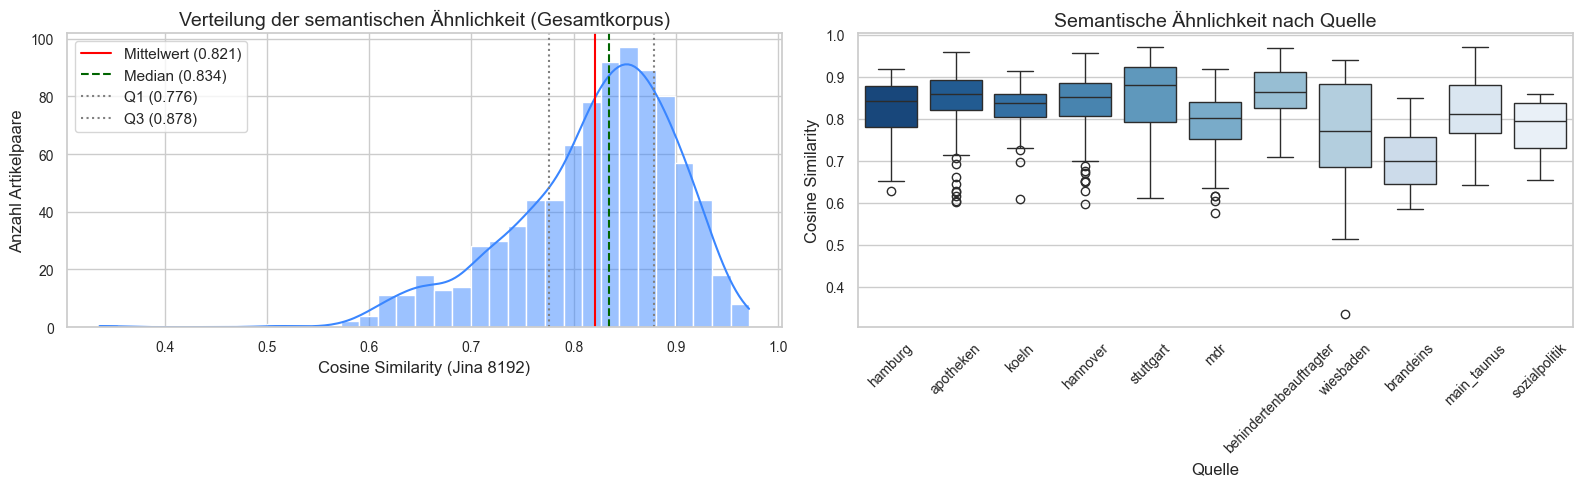

=== Schwellenwert-Verteilung der semantischen Ähnlichkeit ===


,Anzahl,Anteil (%)
sim_category,,
< 0.70 (Niedrig),76,8.616780
0.70 - 0.80 (Moderat),206,23.356009
0.80 - 0.85 (Gut),232,26.303855
0.85 - 0.90 (Sehr gut),244,27.664399
>= 0.90 (Exzellent),124,14.058957


In [9]:
sim_col = "semantic_similarity_8192" if "semantic_similarity_8192" in df.columns else None

if sim_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 4.1 Gesamthistogramm mit KDE und Kennwerten
    mean_sim = df[sim_col].mean()
    median_sim = df[sim_col].median()
    q25, q75 = df[sim_col].quantile(0.25), df[sim_col].quantile(0.75)
    
    sns.histplot(df[sim_col], kde=True, bins=35, color="#3a86ff", ax=axes[0])
    axes[0].axvline(mean_sim, color="red", linestyle="-", label=f"Mittelwert ({mean_sim:.3f})")
    axes[0].axvline(median_sim, color="darkgreen", linestyle="--", label=f"Median ({median_sim:.3f})")
    axes[0].axvline(q25, color="gray", linestyle=":", label=f"Q1 ({q25:.3f})")
    axes[0].axvline(q75, color="gray", linestyle=":", label=f"Q3 ({q75:.3f})")
    axes[0].set_title("Verteilung der semantischen Ähnlichkeit (Gesamtkorpus)")
    axes[0].set_xlabel("Cosine Similarity (Jina 8192)")
    axes[0].set_ylabel("Anzahl Artikelpaare")
    axes[0].legend()
    
    # 4.2 Boxplot nach Quellen
    sns.boxplot(data=df, x="source", y=sim_col, palette="Blues_r", ax=axes[1])
    axes[1].set_title("Semantische Ähnlichkeit nach Quelle")
    axes[1].set_xlabel("Quelle")
    axes[1].set_ylabel("Cosine Similarity")
    axes[1].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 4.3 Schwellenwert-Analyse
    thresholds = [0.0, 0.70, 0.80, 0.85, 0.90, 1.01]
    labels = ["< 0.70 (Niedrig)", "0.70 - 0.80 (Moderat)", "0.80 - 0.85 (Gut)", "0.85 - 0.90 (Sehr gut)", ">= 0.90 (Exzellent)"]
    df["sim_category"] = pd.cut(df[sim_col], bins=thresholds, labels=labels, right=False)
    
    sim_dist = df["sim_category"].value_counts(sort=False).to_frame(name="Anzahl")
    sim_dist["Anteil (%)"] = (sim_dist["Anzahl"] / len(df)) * 100
    print("=== Schwellenwert-Verteilung der semantischen Ähnlichkeit ===")
    display(sim_dist)


## 5. Type-Token Ratio (TTR) Analyse & Längen-Bias

Die klassische **Type-Token Ratio** ($TTR = V/N$) beschreibt den Anteil einzigartiger Wörter an der Gesamtwortzahl.

> [!WARNING]
> **Bekannter TTR-Längen-Bias (Herdan's Law / Zipf's Law):**
> Da die Anzahl neuer Wörter in einem Text mit wachsender Länge degressiv ansteigt, fällt die TTR bei längeren Texten mathematisch bedingt ab. Dies führt dazu, dass längere Alltagssprachen-Texte scheinbar eine geringere TTR haben als kurze Leichte-Sprache-Texte.


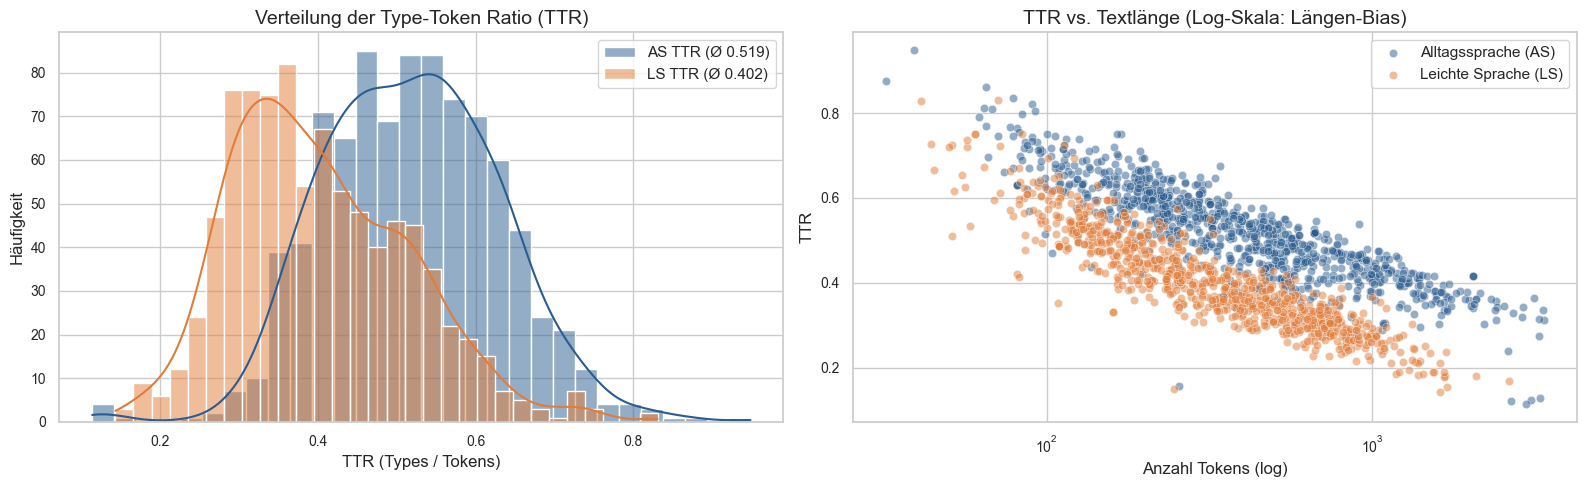

Paarweiser t-Test TTR (AS vs. LS): t = 36.712, p = 9.494e-180


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5.1 Verteilung TTR: AS vs. LS
sns.histplot(df["as_ttr"], kde=True, color="#2b5c8f", label=f"AS TTR (Ø {df['as_ttr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_ttr"], kde=True, color="#e27c38", label=f"LS TTR (Ø {df['ls_ttr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der Type-Token Ratio (TTR)")
axes[0].set_xlabel("TTR (Types / Tokens)")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 5.2 Längen-Bias-Visualisierung: TTR vs. Tokenanzahl
sns.scatterplot(data=df, x="as_tokens", y="as_ttr", color="#2b5c8f", alpha=0.5, label="Alltagssprache (AS)", ax=axes[1])
sns.scatterplot(data=df, x="ls_tokens", y="ls_ttr", color="#e27c38", alpha=0.5, label="Leichte Sprache (LS)", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("TTR vs. Textlänge (Log-Skala: Längen-Bias)")
axes[1].set_xlabel("Anzahl Tokens (log)")
axes[1].set_ylabel("TTR")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistische Auswertung des TTR-Unterschieds
t_stat, p_val = stats.ttest_rel(df["as_ttr"].dropna(), df["ls_ttr"].dropna())
print(f"Paarweiser t-Test TTR (AS vs. LS): t = {t_stat:.3f}, p = {p_val:.3e}")


## 6. Moving-Average Type-Token Ratio (MATTR)

Die **Moving-Average Type-Token Ratio (MATTR)** löst das Problem des Längen-Bias, indem die TTR über ein gleitendes Fenster fester Größe (z. B. $W=50$) gemittelt wird.

Dadurch wird die lexikalische Diversität unabhängig von der Gesamtlänge des Artikels messbar. In Leichter Sprache wird bewusst ein vereinfachtes, wiederholtes Vokabular gewählt, weshalb die MATTR von LS typischerweise signifikant unter der von AS liegt.


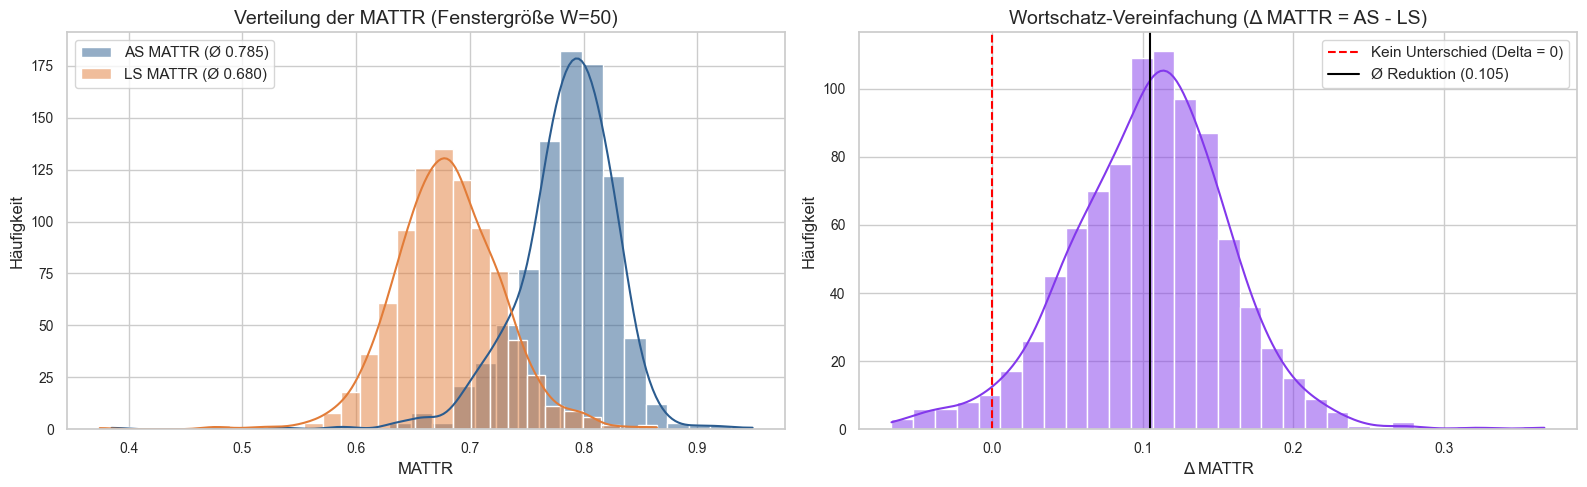

Paarweiser t-Test MATTR (AS vs. LS): t = 58.800, p = 3.124e-307


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 6.1 Verteilung MATTR: AS vs. LS
sns.histplot(df["as_mattr"], kde=True, color="#2b5c8f", label=f"AS MATTR (Ø {df['as_mattr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_mattr"], kde=True, color="#e27c38", label=f"LS MATTR (Ø {df['ls_mattr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der MATTR (Fenstergröße W=50)")
axes[0].set_xlabel("MATTR")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 6.2 Differenz (Delta MATTR = AS - LS)
df["delta_mattr"] = df["as_mattr"] - df["ls_mattr"]
sns.histplot(df["delta_mattr"], kde=True, color="#8338ec", bins=30, ax=axes[1])
axes[1].axvline(0.0, color="red", linestyle="--", label="Kein Unterschied (Delta = 0)")
axes[1].axvline(df["delta_mattr"].mean(), color="black", linestyle="-", label=f"Ø Reduktion ({df['delta_mattr'].mean():.3f})")
axes[1].set_title("Wortschatz-Vereinfachung (Δ MATTR = AS - LS)")
axes[1].set_xlabel("Δ MATTR")
axes[1].set_ylabel("Häufigkeit")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistische Auswertung des MATTR-Unterschieds
t_stat_m, p_val_m = stats.ttest_rel(df["as_mattr"].dropna(), df["ls_mattr"].dropna())
print(f"Paarweiser t-Test MATTR (AS vs. LS): t = {t_stat_m:.3f}, p = {p_val_m:.3e}")


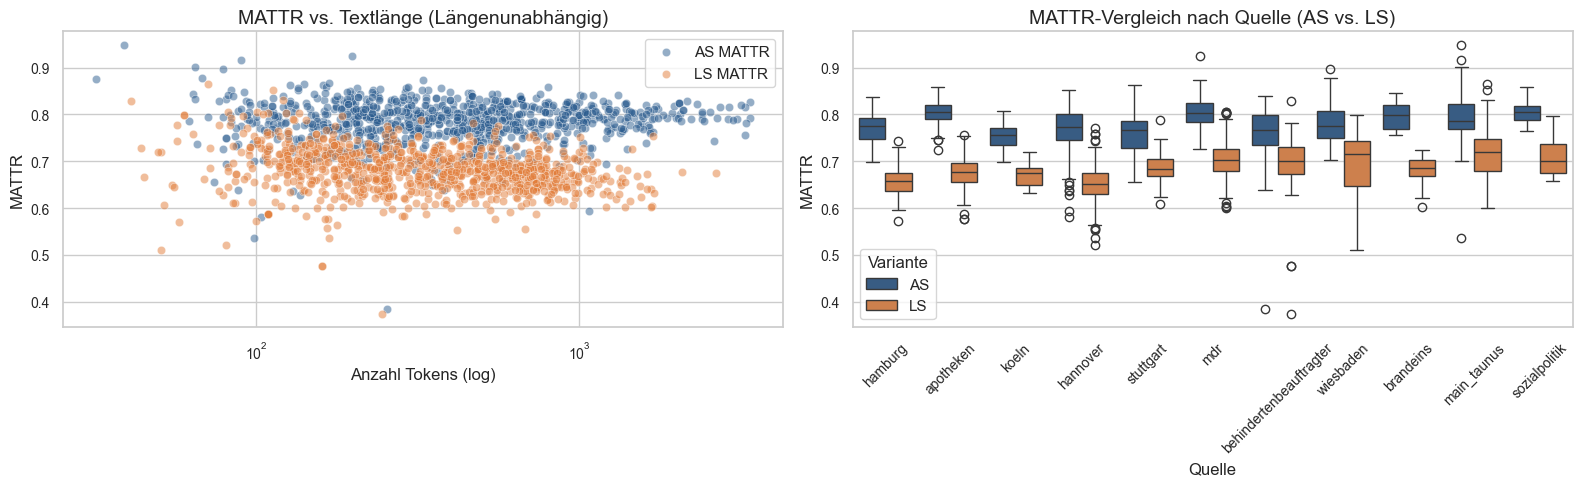

In [12]:
# 6.3 Direkter Vergleich: TTR vs. MATTR nach Textlänge
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MATTR vs. Tokens (Demonstration der Längenunabhängigkeit)
sns.scatterplot(data=df, x="as_tokens", y="as_mattr", color="#2b5c8f", alpha=0.5, label="AS MATTR", ax=axes[0])
sns.scatterplot(data=df, x="ls_tokens", y="ls_mattr", color="#e27c38", alpha=0.5, label="LS MATTR", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("MATTR vs. Textlänge (Längenunabhängig)")
axes[0].set_xlabel("Anzahl Tokens (log)")
axes[0].set_ylabel("MATTR")
axes[0].legend()

# Boxplot MATTR nach Quellen
df_mattr_melted = df.melt(id_vars=["source"], value_vars=["as_mattr", "ls_mattr"], 
                          var_name="Variante", value_name="MATTR")
df_mattr_melted["Variante"] = df_mattr_melted["Variante"].map({"as_mattr": "AS", "ls_mattr": "LS"})

sns.boxplot(data=df_mattr_melted, x="source", y="MATTR", hue="Variante", palette=["#2b5c8f", "#e27c38"], ax=axes[1])
axes[1].set_title("MATTR-Vergleich nach Quelle (AS vs. LS)")
axes[1].set_xlabel("Quelle")
axes[1].set_ylabel("MATTR")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [14]:
# Zusammenfassende Kennzahlentabelle für die Masterarbeit
metrics_summary = df[available_cols].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
metrics_summary.columns = ["N", "Mittelwert", "Std", "Min", "Q1", "Median", "Q3", "Max"]
print("=== Zusammenfassende Statistik aller Korpusmetriken ===")
display(metrics_summary.round(3))


=== Zusammenfassende Statistik aller Korpusmetriken ===


,N,Mittelwert,Std,Min,Q1,Median,Q3,Max
semantic_similarity_8192,882.0,0.821,0.080,0.336,0.776,0.834,0.878,0.972
as_tokens,882.0,562.186,544.291,32.000,210.000,374.500,675.000,3387.000
ls_tokens,882.0,427.921,329.910,41.000,175.250,325.500,612.750,2645.000
ratio_ls_as,882.0,0.992,0.613,0.192,0.532,0.835,1.318,3.955
as_ttr,882.0,0.519,0.111,0.114,0.437,0.518,0.595,0.949
ls_ttr,882.0,0.402,0.113,0.143,0.315,0.387,0.481,0.831
as_mattr,882.0,0.785,0.045,0.385,0.765,0.790,0.812,0.949
ls_mattr,882.0,0.680,0.048,0.374,0.651,0.680,0.710,0.865
delta_mattr,882.0,0.105,0.053,-0.067,0.073,0.107,0.138,0.367
